In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/solar_energy_dataset.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Timestamp,Installation_ID,Solar_Generation,Sunlight,Temperature,Cloud_Cover,Panel_Condition
0,2025-01-01 00:00:00,SOLAR_001,0.00,2.84,15.44,23.37,99.78
1,2025-01-01 01:00:00,SOLAR_001,0.00,0.00,16.99,8.56,100.00
2,2025-01-01 02:00:00,SOLAR_001,0.00,0.00,17.29,19.68,99.42
3,2025-01-01 03:00:00,SOLAR_001,0.14,0.00,16.72,8.29,99.23
4,2025-01-01 04:00:00,SOLAR_001,0.00,38.52,16.97,38.17,99.58


In [ ]:
# Display data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Timestamp         52560 non-null  object 
 1   Installation_ID   52560 non-null  object 
 2   Solar_Generation  52560 non-null  float64
 3   Sunlight          52560 non-null  float64
 4   Temperature       52560 non-null  float64
 5   Cloud_Cover       52560 non-null  float64
 6   Panel_Condition   52560 non-null  float64
dtypes: float64(5), object(2)
memory usage: 2.8+ MB


In [ ]:
# Convert 'Timestamp' to datetime objects
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Display the updated info to confirm the change
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Timestamp         52560 non-null  datetime64[ns]
 1   Installation_ID   52560 non-null  object        
 2   Solar_Generation  52560 non-null  float64       
 3   Sunlight          52560 non-null  float64       
 4   Temperature       52560 non-null  float64       
 5   Cloud_Cover       52560 non-null  float64       
 6   Panel_Condition   52560 non-null  float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 2.8+ MB


In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 Timestamp           0
Installation_ID     0
Solar_Generation    0
Sunlight            0
Temperature         0
Cloud_Cover         0
Panel_Condition     0
dtype: int64


In [ ]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Timestamp,Solar_Generation,Sunlight,Temperature,Cloud_Cover,Panel_Condition
count,52560,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000
mean,2025-07-02 11:30:00,65.654180,223.044427,26.194108,28.535837,98.654232
min,2025-01-01 00:00:00,0.000000,0.000000,10.070000,0.170000,92.730000
25%,2025-04-02 05:45:00,0.000000,0.000000,20.900000,16.670000,97.920000
50%,2025-07-02 11:30:00,4.855000,49.985000,26.210000,26.560000,98.880000
75%,2025-10-01 17:15:00,115.452500,451.442500,31.400000,38.490000,99.760000
max,2025-12-31 23:00:00,542.590000,1045.280000,46.710000,92.450000,100.000000
std,NaN,97.492179,265.705169,6.314938,15.299982,1.238443


In [ ]:
# Extract time-based features from 'Timestamp' for daily and seasonal pattern analysis
df['Hour'] = df['Timestamp'].dt.hour
df['Day_of_Week'] = df['Timestamp'].dt.dayofweek  # Monday=0, Sunday=6
df['Day_of_Year'] = df['Timestamp'].dt.dayofyear
df['Month'] = df['Timestamp'].dt.month
df['Season'] = (df['Month'] % 12 + 3) // 3 # Simple season mapping: 1=Winter, 2=Spring, 3=Summer, 4=Autumn

# Display the first few rows with new features
display(df.head())

,Timestamp,Installation_ID,Solar_Generation,Sunlight,Temperature,Cloud_Cover,Panel_Condition,Hour,Day_of_Week,Day_of_Year,Month,Season
0,2025-01-01 00:00:00,SOLAR_001,0.00,2.84,15.44,23.37,99.78,0,2,1,1,1
1,2025-01-01 01:00:00,SOLAR_001,0.00,0.00,16.99,8.56,100.00,1,2,1,1,1
2,2025-01-01 02:00:00,SOLAR_001,0.00,0.00,17.29,19.68,99.42,2,2,1,1,1
3,2025-01-01 03:00:00,SOLAR_001,0.14,0.00,16.72,8.29,99.23,3,2,1,1,1
4,2025-01-01 04:00:00,SOLAR_001,0.00,38.52,16.97,38.17,99.58,4,2,1,1,1


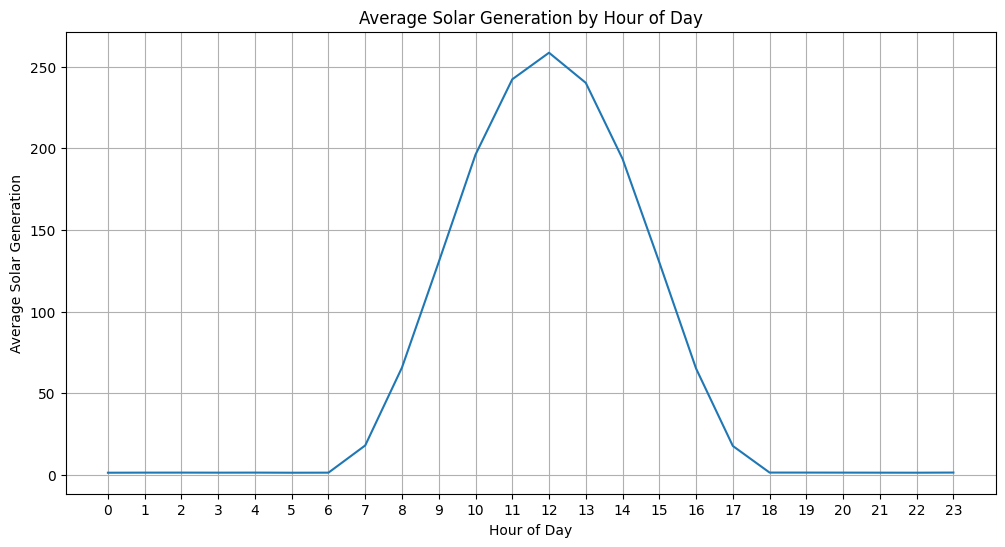

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot average Solar_Generation by Hour
plt.figure(figsize=(12, 6))
sns.lineplot(x='Hour', y='Solar_Generation', data=df.groupby('Hour')['Solar_Generation'].mean().reset_index())
plt.title('Average Solar Generation by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Solar Generation')
plt.grid(True)
plt.xticks(range(0, 24))
plt.show()

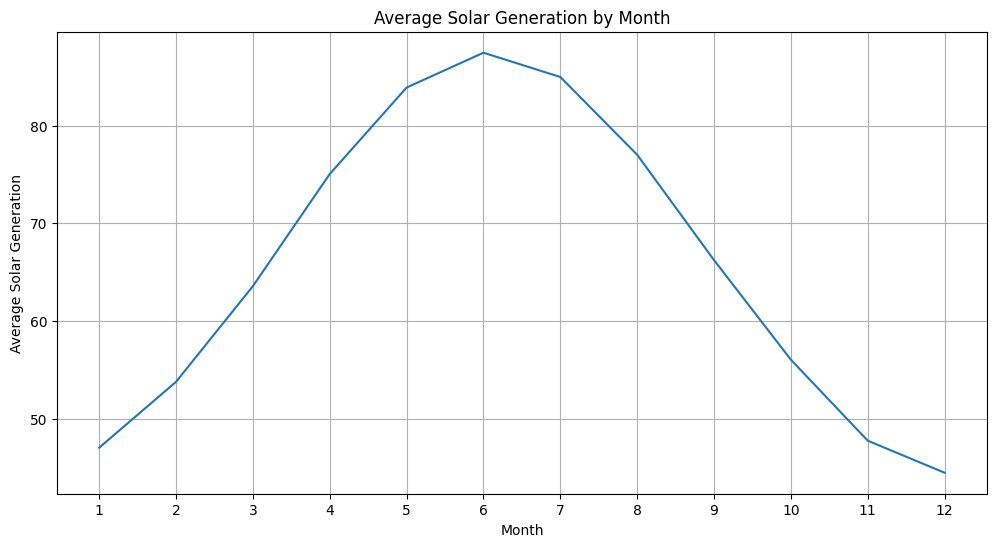

In [ ]:
# Plot average Solar_Generation by Month
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Solar_Generation', data=df.groupby('Month')['Solar_Generation'].mean().reset_index())
plt.title('Average Solar Generation by Month')
plt.xlabel('Month')
plt.ylabel('Average Solar Generation')
plt.grid(True)
plt.xticks(range(1, 13))
plt.show()

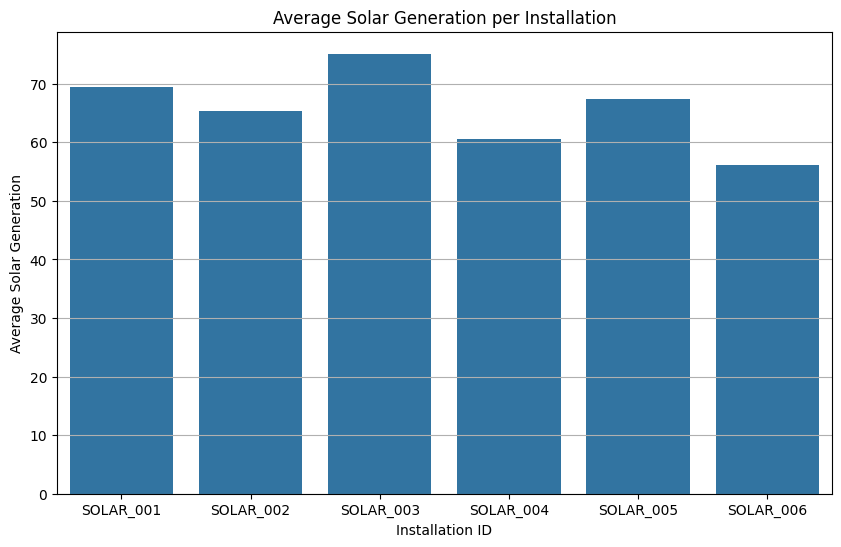

In [ ]:
# Compare installations: average solar generation per installation
plt.figure(figsize=(10, 6))
sns.barplot(x='Installation_ID', y='Solar_Generation', data=df.groupby('Installation_ID')['Solar_Generation'].mean().reset_index())
plt.title('Average Solar Generation per Installation')
plt.xlabel('Installation ID')
plt.ylabel('Average Solar Generation')
plt.grid(axis='y')
plt.show()

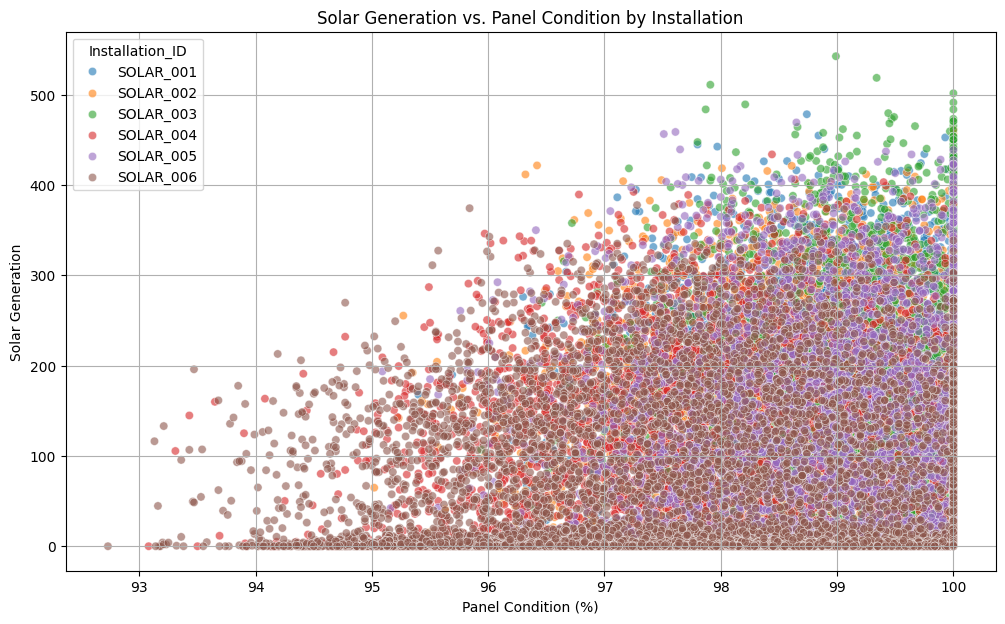

In [ ]:
# Identify potentially underperforming panels by plotting Solar_Generation vs. Panel_Condition
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Panel_Condition', y='Solar_Generation', hue='Installation_ID', data=df, alpha=0.6)
plt.title('Solar Generation vs. Panel Condition by Installation')
plt.xlabel('Panel Condition (%)')
plt.ylabel('Solar Generation')
plt.grid(True)
plt.show()

## Key Insights from Exploratory Data Analysis

1.  **Diurnal Pattern:** Solar generation exhibits a clear diurnal pattern, peaking around noon (12-13 hours) and being close to zero during night hours (18-6 hours). This is expected as sunlight is the primary driver of solar energy. (Visualized in 'Average Solar Generation by Hour of Day').
2.  **Seasonal Pattern:** There's a strong seasonal trend, with solar generation being highest in summer months (June-July) and lowest in winter months (December-January). This correlates with longer daylight hours and higher sun intensity during summer. (Visualized in 'Average Solar Generation by Month').
3.  **Installation Performance Variation:** There are noticeable differences in average solar generation across different installations. 'SOLAR_003' appears to have the highest average generation, while 'SOLAR_006' has the lowest. This suggests variations in installation size, location, or efficiency. (Visualized in 'Average Solar Generation per Installation').
4.  **Panel Condition Impact:** There's a positive correlation between 'Panel_Condition' and 'Solar_Generation'. Installations with higher panel condition percentages tend to achieve higher solar generation. This highlights the importance of panel maintenance. (Visualized in 'Solar Generation vs. Panel Condition by Installation').
5.  **Potential for Underperforming Panels:** The scatter plot of 'Solar Generation vs. Panel Condition' shows some instances where panels with relatively high 'Panel_Condition' still exhibit lower 'Solar_Generation' compared to others, and vice-versa. This might indicate other factors at play or potential issues not solely captured by 'Panel_Condition'.
6.  **No Missing Values:** The dataset is clean with no missing values, which simplifies the data preparation phase.
7.  **Data Types are Appropriate:** After converting 'Timestamp' to datetime objects, all columns have appropriate data types for further analysis and modeling.

## Model Building: XGBoost for Solar Generation Prediction

To predict solar generation, we will build an XGBoost Regressor model. Before training, we need to prepare the data by encoding categorical features and splitting the dataset into training and testing sets.

In [10]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define the path to the dataset, using the corrected uploaded filename
dataset_path = '/content/solar_energy_dataset (1).csv'

# Load the dataset
df = pd.read_csv(dataset_path)

# Convert 'Timestamp' to datetime objects
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extract time-based features from 'Timestamp' for daily and seasonal pattern analysis
df['Hour'] = df['Timestamp'].dt.hour
df['Day_of_Week'] = df['Timestamp'].dt.dayofweek  # Monday=0, Sunday=6
df['Day_of_Year'] = df['Timestamp'].dt.dayofyear
df['Month'] = df['Timestamp'].dt.month
df['Season'] = (df['Month'] % 12 + 3) // 3 # Simple season mapping: 1=Winter, 2=Spring, 3=Summer, 4=Autumn

# Define features (X) and target (y)
X = df.drop(['Timestamp', 'Solar_Generation'], axis=1)
y = df['Solar_Generation']

# Identify categorical and numerical features
categorical_features = ['Installation_ID', 'Day_of_Week', 'Month', 'Season']
numerical_features = ['Sunlight', 'Temperature', 'Cloud_Cover', 'Panel_Condition', 'Hour', 'Day_of_Year']

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ],
    remainder='passthrough' # Keep other columns (if any) that are not in defined lists
)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (42048, 10)
X_test shape: (10512, 10)
y_train shape: (42048,)
y_test shape: (10512,)


In [7]:
from google.colab import files

# Upload the dataset file
print("Please upload the 'solar_energy_dataset.csv' file:")
uploaded = files.upload()

# Verify that the file was uploaded
if 'solar_energy_dataset.csv' in uploaded:
    print("File 'solar_energy_dataset.csv' uploaded successfully!")
else:
    print("File upload failed or the file name is incorrect. Please ensure you upload 'solar_energy_dataset.csv'.")

Please upload the 'solar_energy_dataset.csv' file:


Saving solar_energy_dataset.csv to solar_energy_dataset (1).csv
File upload failed or the file name is incorrect. Please ensure you upload 'solar_energy_dataset.csv'.


Now that the data is prepared, we can train the XGBoost model. We will then evaluate its performance and examine feature importance.

In [12]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create the XGBoost Regressor model pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=5)) # Added common hyperparameters
])

# Train the model
print("Training XGBoost model...")
model.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Training XGBoost model...
Model training complete.

Model Evaluation:
Mean Absolute Error (MAE): 3.31
Root Mean Squared Error (RMSE): 5.24
R-squared (R2): 1.00



Top 10 Feature Importances:


,Feature,Importance
29,num__Sunlight,0.853498
2,cat__Installation_ID_SOLAR_003,0.033824
5,cat__Installation_ID_SOLAR_006,0.032154
3,cat__Installation_ID_SOLAR_004,0.020321
0,cat__Installation_ID_SOLAR_001,0.013234
4,cat__Installation_ID_SOLAR_005,0.007624
31,num__Cloud_Cover,0.006145
33,num__Hour,0.004598
32,num__Panel_Condition,0.004038
1,cat__Installation_ID_SOLAR_002,0.003620


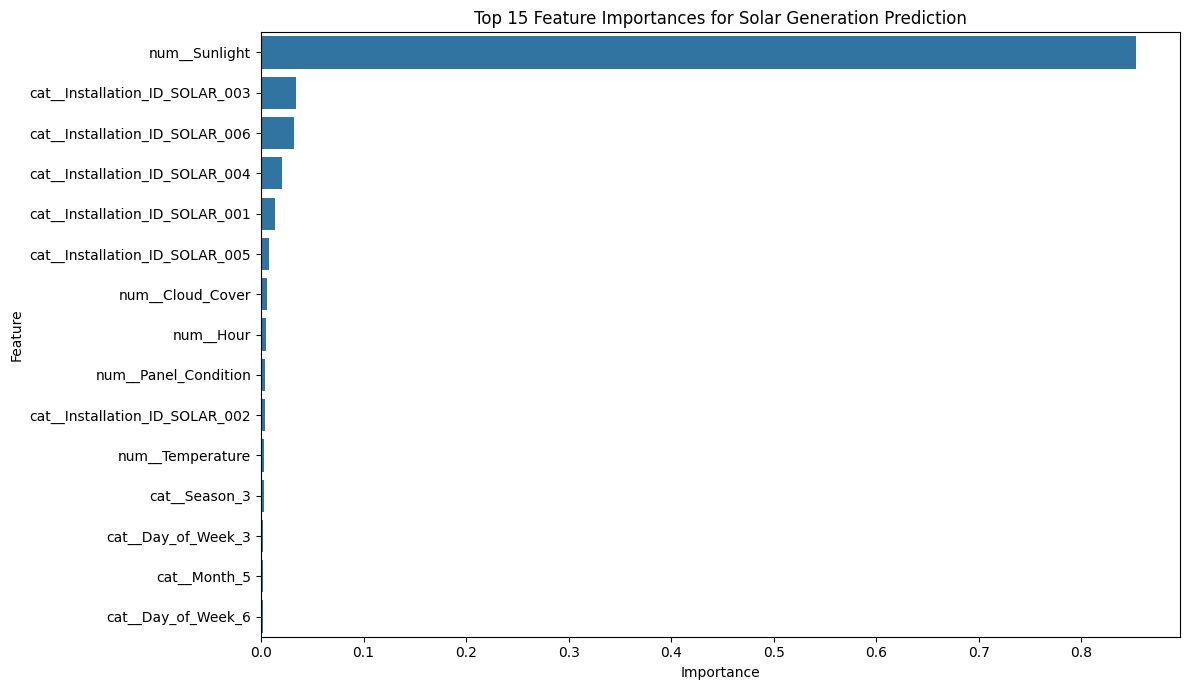

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported for DataFrame operations if not already global

# Feature Importance
# Get feature names after one-hot encoding
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# Get feature importances from the trained XGBoost regressor
importances = model.named_steps['regressor'].feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Feature Importances:")
display(feature_importance_df.head(10))

# Plot feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15))
plt.title('Top 15 Feature Importances for Solar Generation Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Practical Action Plan

Based on the data analysis, visualizations, and the trained XGBoost model, here's a practical action plan to improve monitoring and maintenance of the solar installations:

1.  **Optimize Solar Panel Orientation and Cleaning Schedules:**
    *   **Action:** Leverage the strong diurnal and seasonal patterns (highest generation at midday, highest in summer) to schedule panel cleaning and maintenance during low generation periods or off-peak hours to minimize disruption. Ensure panels are optimally angled for maximum sunlight capture, especially in months with lower generation.
    *   **Rationale:** Maximize energy capture by ensuring panels are clean and well-oriented, directly addressing the impact of 'Sunlight' and 'Hour' on generation.

2.  **Prioritize Maintenance for Underperforming Installations/Panels:**
    *   **Action:** Focus maintenance efforts on installations like 'SOLAR_006' that consistently show lower average generation. Further investigate specific panels within any installation that show a discrepancy between 'Panel_Condition' and 'Solar_Generation' (i.e., good condition but low output) as identified in the scatter plot.
    *   **Rationale:** Targeted maintenance can significantly improve overall system efficiency and return on investment. The model's insights into 'Panel_Condition' importance reinforce this.

3.  **Implement Advanced Weather Monitoring and Predictive Maintenance:**
    *   **Action:** Integrate real-time weather data (Sunlight, Temperature, Cloud_Cover) into the monitoring system. Develop alerts for anticipated significant drops in solar generation due to adverse weather conditions (e.g., heavy cloud cover, extreme temperatures) using the XGBoost model's predictions.
    *   **Rationale:** Proactive identification of low generation periods allows for better energy management and grid integration. The high importance of 'Sunlight' and 'Cloud_Cover' in the model supports this.

4.  **Continuous Monitoring of Panel Condition:**
    *   **Action:** Implement or enhance a system for regular, possibly automated, assessment of 'Panel_Condition'. This could involve drone inspections, visual analytics, or sensors. Promptly address any degradation in panel condition.
    *   **Rationale:** 'Panel_Condition' is a significant predictor of solar generation. Maintaining high panel condition directly translates to better performance and extends asset lifespan.

5.  **Investigate 'Abnormal Drops in Output':**
    *   **Action:** Utilize the trained XGBoost model to set thresholds for expected solar generation given current weather and panel conditions. Any significant deviation below the predicted value should trigger an alert for further investigation (e.g., equipment malfunction, unexpected shading, localized weather events).
    *   **Rationale:** The model provides a baseline for expected performance, making it easier to identify and diagnose anomalies that might indicate underlying issues beyond predictable environmental factors.

6.  **Refine Predictive Model with More Granular Data (if available):**
    *   **Action:** Continuously collect more granular data, especially on individual panel performance, specific weather phenomena (e.g., fog, precipitation types), and maintenance logs. Retrain and refine the XGBoost model periodically with new data.
    *   **Rationale:** An even more accurate model can provide finer-grained predictions and insights, leading to more precise interventions and better operational efficiency.